This project investigates the impact of weight decay on model regularization. By using a limited training set to guide the model into an Overfitting state, I contrast the learning curves of regularized and non-regularized models to show the effectiveness of weight decay in reducing overfitting.

In [13]:
import torch 
from torch import nn
import matplotlib.pyplot as plt

In [14]:
def make_data(n_train,n_net,n_inputs,device):
    true_w, true_b = torch.ones((n_inputs, 1), device=device) * 0.01, 0.05
    
    train_X = torch.randn((n_train, n_inputs), device=device)
    test_X = torch.randn((n_test, n_inputs), device=device)

    #加入噪声
    train_y = torch.matmul(train_X, true_w) + true_b 
    train_y += torch.normal(0, 0.01, train_y.shape, device=device)
    test_y = torch.matmul(test_X, true_w) + true_b
    test_y += torch.normal(0, 0.01, test_y.shape, device=device)

    return train_X, train_y, test_X, test_y

In [15]:
def train_with_wd(wd, n_train, n_test, n_inputs, device, lr=0.003, num_epochs=100):
    train_X, train_y, test_X, test_y = make_data(n_train, n_test, n_inputs, device)

    net = nn.Sequential(nn.Linear(n_inputs, 1)).to(device)
    for param in net.parameters():
        nn.init.normal_(param, std=1)
 

    loss = nn.MSELoss(reduction='none')   
    trainer = torch.optim.SGD(net.parameters(), lr=lr, weight_decay=wd)
    train_ls, test_ls = [], []
    
    for epoch in range(num_epochs):
        net.train()
        l = loss(net(train_X), train_y).mean()
        trainer.zero_grad()
        l.backward()
        trainer.step()

        with torch.no_grad():
            net.eval()
            train_ls.append(loss(net(train_X), train_y).mean().item())
            test_ls.append(loss(net(test_X), test_y).mean().item())

    return train_ls, test_ls


In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_train, n_test, n_inputs = 20, 100, 200#训练样本很少，故意引导模型过拟合

In [17]:
train_ls_no_wd, test_ls_no_wd = train_with_wd(0, n_train, n_test, n_inputs, device)
train_ls_with_wd, test_ls_with_wd = train_with_wd(5, n_train, n_test, n_inputs, device)

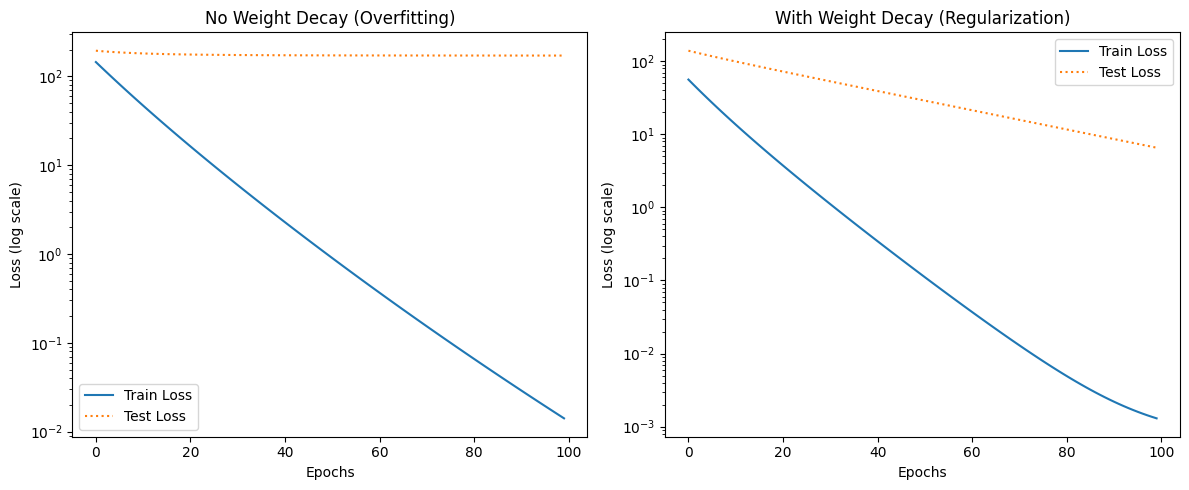

In [18]:
plt.figure(figsize=(12, 5))

#without weight decay
plt.subplot(1, 2, 1)
plt.semilogy(train_ls_no_wd, label='Train Loss')
plt.semilogy(test_ls_no_wd, linestyle=':', label='Test Loss')
plt.title('No Weight Decay (Overfitting)')
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.legend()

#with weight decay
plt.subplot(1, 2, 2)
plt.semilogy(train_ls_with_wd, label='Train Loss')
plt.semilogy(test_ls_with_wd, linestyle=':', label='Test Loss')
plt.title('With Weight Decay (Regularization)')
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.legend()

plt.tight_layout()
plt.show()